SQL- Python Script

Import Libraries

In [26]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

Connect to Duckdb

In [6]:
conn = duckdb.connect("../database/wine_database.duckdb")
cur = conn.cursor()

In [7]:
# Ensure region columns are synonimous

cur.execute("""ALTER TABLE winemag_clean ADD COLUMN region_clean TEXT;
UPDATE winemag_clean
SET region_clean = 
    CASE 
        WHEN region_1 IS NOT NULL AND region_1 <> '' THEN region_1
        ELSE region_2
    END;
""")

CatalogException: Catalog Error: Column with name region_clean already exists!

In [8]:
cur.execute("""UPDATE winemag_clean
SET region_clean = 
    CASE
        WHEN region_clean = 'Loire Valley' THEN 'Loire'
        WHEN region_clean = 'Bourgogne' THEN 'Burgundy'
        WHEN region_clean = 'Cote de Beaune' THEN 'Côte De Beaune'
        ELSE region_clean
    END;

""")

In [9]:
conn.execute("SHOW TABLES").fetchall()

[('grape_quality_clean',), ('vivino_clean',), ('winemag_clean',)]

In [10]:
conn.execute("SELECT * FROM winemag_clean LIMIT 5").df()

,variety,winery,country,province,region_1,region_2,points,price,region_clean
0,White Blend,Nicosia,Italy,Sicily & Sardinia,Etna,None,87,NaN,Etna
1,Portuguese Red,Quinta Dos Avidagos,Portugal,Douro,None,None,87,15.0,None
2,Pinot Gris,Rainstorm,Us,Oregon,Willamette Valley,Willamette Valley,87,14.0,Willamette Valley
3,Riesling,St. Julian,Us,Michigan,Lake Michigan Shore,None,87,13.0,Lake Michigan Shore
4,Pinot Noir,Sweet Cheeks,Us,Oregon,Willamette Valley,Willamette Valley,87,65.0,Willamette Valley


In [11]:
conn.execute("SELECT * FROM vivino_clean LIMIT 5").df()

,country,rating,wine_name,winery_name,ratings_count,wine_type,region,is_natural
0,Chile,3.9,Reserva Especial Carménère,Terranoble,341,Red,Aconcagua Valley,False
1,Australia,3.3,Regional Series Chardonnay,Lindeman's,666,White,Adelaide Hills,False
2,Argentina,3.6,Alto Agrelo Grande Reserve Malbec,Alta Vista,154,Red,Agrelo,False
3,Argentina,4.0,Lote Agrelo Malbec,Bodega Norton,2088,Red,Agrelo,False
4,Argentina,3.9,Appellation Agrelo Cabernet Sauvignon,Catena,3850,Red,Agrelo,False


In [12]:
conn.execute("SELECT * FROM grape_quality_clean LIMIT 5").df()

,sample_id,variety,region,quality_score,quality_category,sugar_content_brix,acidity_ph,cluster_weight_g,berry_size_mm,harvest_date,sun_exposure_hours,soil_moisture_percent,rainfall_mm
0,1,Riesling,Barossa Valley,2.11,Medium,13.70,3.17,251.81,18.58,2023-09-04,8.4,55.9,223.3
1,2,Pinot Noir,Loire Valley,2.83,High,20.84,3.15,289.00,22.08,2023-09-16,8.8,36.9,312.1
2,3,Sauvignon Blanc,Napa Valley,3.52,Premium,27.46,4.07,125.14,21.40,2023-08-25,11.1,64.9,698.7
3,4,Riesling,Napa Valley,2.28,Medium,24.64,3.15,237.46,12.31,2023-09-13,8.0,54.5,660.1
4,5,Merlot,Napa Valley,2.90,High,26.13,3.18,221.52,12.24,2023-08-11,11.2,36.3,410.4


In [13]:
df = conn.execute("""
-- See what's actually in each table
SELECT DISTINCT region FROM grape_quality_clean ORDER BY region;
SELECT DISTINCT region FROM vivino_clean WHERE country = 'France' ORDER BY region;
                  """).df()
df

,region
0,Alsace
1,Bordeaux
2,Bourgogne
3,Chablis
4,Champagne
5,Côte De Beaune
6,Loire Valley
7,Pessac-Léognan
8,Rhone Valley


In [14]:
conn.execute("""
    SELECT DISTINCT variety
    FROM grape_quality_clean
    WHERE region IN ('Bordeaux', 'Loire Valley')
    ORDER BY variety
""").df()

,variety
0,Cabernet Sauvignon
1,Chardonnay
2,Merlot
3,Pinot Noir
4,Riesling
5,Sauvignon Blanc
6,Syrah
7,Zinfandel


In [15]:
conn.execute("DESCRIBE vivino_clean").df()

,column_name,column_type,null,key,default,extra
0,country,VARCHAR,YES,None,None,None
1,rating,DOUBLE,YES,None,None,None
2,wine_name,VARCHAR,YES,None,None,None
3,winery_name,VARCHAR,YES,None,None,None
4,ratings_count,INTEGER,YES,None,None,None
5,wine_type,VARCHAR,YES,None,None,None
6,region,VARCHAR,YES,None,None,None
7,is_natural,BOOLEAN,YES,None,None,None


In [16]:
conn.execute("DESCRIBE winemag_clean").df()

,column_name,column_type,null,key,default,extra
0,variety,VARCHAR,YES,None,None,None
1,winery,VARCHAR,YES,None,None,None
2,country,VARCHAR,YES,None,None,None
3,province,VARCHAR,YES,None,None,None
4,region_1,VARCHAR,YES,None,None,None
5,region_2,VARCHAR,YES,None,None,None
6,points,BIGINT,YES,None,None,None
7,price,DOUBLE,YES,None,None,None
8,region_clean,VARCHAR,YES,None,None,None


In [17]:
conn.execute("""
    SELECT MIN(price), MAX(price), AVG(price), COUNT(*)
    FROM winemag_clean
    WHERE price IS NOT NULL
""").df()

,min(price),max(price),avg(price),count_star()
0,4.0,3300.0,34.749542,200724


In [18]:
conn.execute("""
    SELECT
        country,
        variety,
        price,
        points,
        winery
    FROM winemag_clean
    WHERE price IS NOT NULL
      AND points IS NOT NULL
      AND country IN ('France', 'Italy', 'US', 'Spain', 'Argentina')
    
""").df()

,country,variety,price,points,winery
0,Spain,Tempranillo-Merlot,15.0,87,Tandem
1,Italy,Frappato,16.0,87,Terre Di Giurfo
2,France,Gewürztraminer,24.0,87,Trimbach
3,France,Pinot Gris,27.0,87,Jean-Baptiste Adam
4,France,Gewürztraminer,30.0,87,Leon Beyer
...,...,...,...,...,...
72468,Spain,Albariño,17.0,89,Nessa
72469,Italy,Carricante,80.0,89,Benanti
72470,Italy,Grillo,15.0,89,Caruso & Minini
72471,Italy,Nerello Mascalese,52.0,89,Cottanera


In [19]:
# See wine cost
conn.execute("""
    SELECT MIN(price), MAX(price), AVG(price), COUNT(*)
    FROM winemag_clean
    WHERE price IS NOT NULL
      AND price <= 200
""").df()

,min(price),max(price),avg(price),count_star()
0,4.0,200.0,32.78307,199539


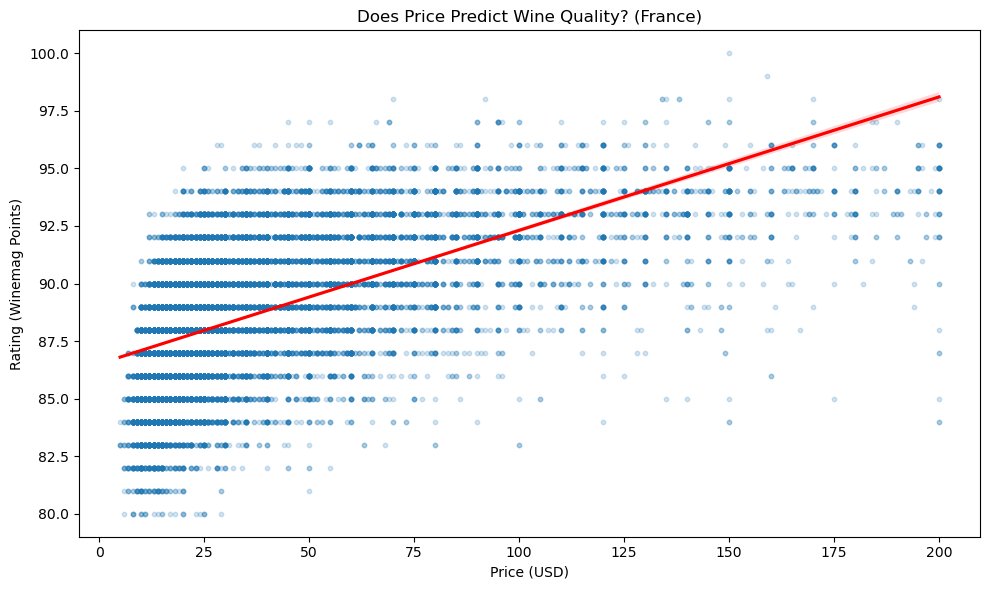

In [20]:
df_france = conn.execute("""
    SELECT variety, price, points
    FROM winemag_clean
    WHERE price IS NOT NULL
      AND points IS NOT NULL
      AND price <= 200
      AND country = 'France'
""").df()

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(
    data=df_france,
    x='price',
    y='points',
    scatter_kws={'alpha': 0.2, 's': 10},
    line_kws={'color': 'red'},
    ax=ax
)

ax.set_title('Does Price Predict Wine Quality? (France)')
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Rating (Winemag Points)')
plt.tight_layout()
plt.show()

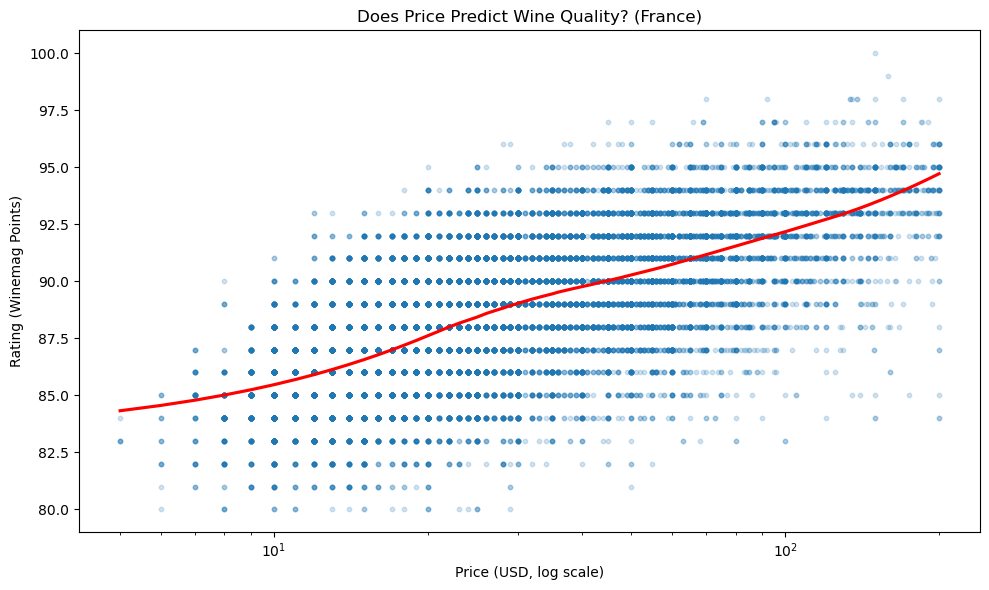

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(
    data=df_france,
    x='price',
    y='points',
    scatter_kws={'alpha': 0.2, 's': 10},
    line_kws={'color': 'red'},
    lowess=True,
    ax=ax
)

ax.set_xscale('log')
ax.set_title('Does Price Predict Wine Quality? (France)')
ax.set_xlabel('Price (USD, log scale)')
ax.set_ylabel('Rating (Winemag Points)')
plt.tight_layout()
plt.show()

In [22]:
df_value = conn.execute("""
    SELECT variety, price, points, winery
    FROM winemag_clean
    WHERE country = 'France'
      AND points >= 90
      AND price <= 20
      AND price IS NOT NULL
      AND variety IS NOT NULL
    ORDER BY points DESC, price ASC
""").df()

print(df_value['variety'].nunique())
df_value.head(10)

60


,variety,price,points,winery
0,Red Blend,20.0,95,Alain Brumont
1,Petit Manseng,18.0,94,Domaine Cauhapé
2,Malbec,20.0,94,Château Du Cèdre
3,Red Blend,20.0,94,Alain Brumont
4,Rosé,20.0,94,Château Vignelaure
5,Gamay,20.0,94,Domaines Dominique Piron
6,White Blend,20.0,94,Domaine Marcel Deiss
7,Red Blend,20.0,94,Alain Brumont
8,Malbec,20.0,94,Château Du Cèdre
9,Rosé,20.0,94,Château Vignelaure


In [23]:
top_varieties = df_value['variety'].value_counts().head(10).index
df_plot = df_value[df_value['variety'].isin(top_varieties)].copy()

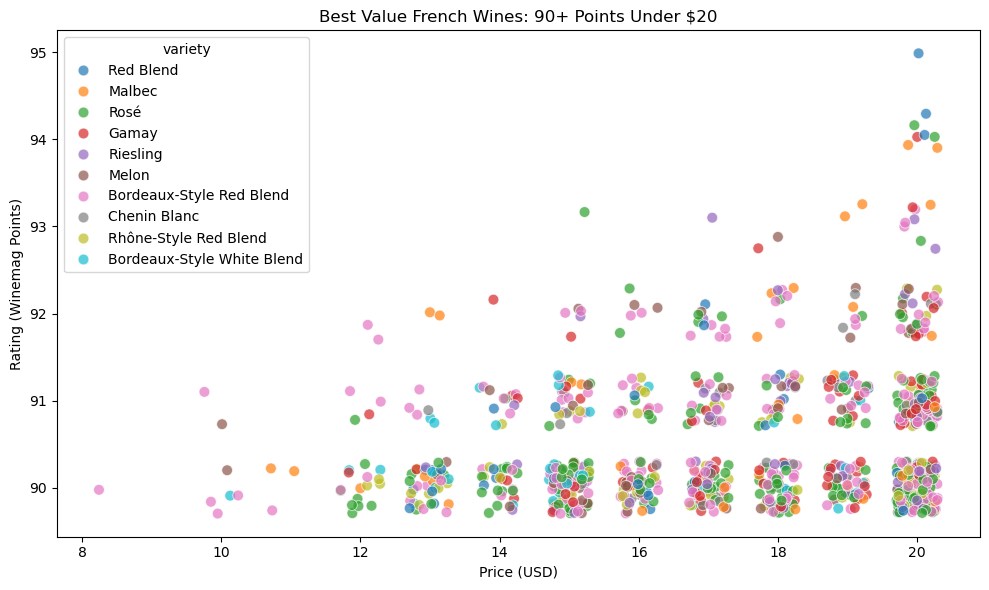

In [27]:
df_plot['points_jittered'] = df_plot['points'] + np.random.uniform(-0.3, 0.3, len(df_plot))
df_plot['price_jittered'] = df_plot['price'] + np.random.uniform(-0.3, 0.3, len(df_plot))

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df_plot,
    x='price_jittered',
    y='points_jittered',
    hue='variety',
    alpha=0.7,
    s=60,
    ax=ax
)

ax.set_title('Best Value French Wines: 90+ Points Under $20')
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Rating (Winemag Points)')
plt.tight_layout()
plt.show()

In [23]:
# Close the connection
conn.close()